# Comparing of several optimization methods

In this example we will compare the most common optimization methods for training neural networks and solving different optimization problems. We will consider the following optimization methods: Adam, RMSprop, SGD, and Adagrad. We will use the same optimization problem for all methods and compare their convergence behavior and performance. Particularly, we will find the minimum of the Rosenbrock function, which is a common test function for optimization algorithms. The Roesenbrock function is defined as:
$$f(x, y) = (a - x)^2 + b(y - x^2)^2$$

where $a$ and $b$ are constants. The function has a global minimum at $(x, y) = (a, a^2)$, where $f(a, a^2) = 0$. The Rosenbrock function is non-convex and has a narrow, curved valley that contains the global minimum, making it a challenging optimization problem for many algorithms. We will compare the convergence of the optimization methods by plotting the optimization trajectories and the value of the function over iterations.

Firstly, we will define the Rosenbrock function and its gradient, which are necessary for the optimization algorithms. We will also set the initial point for the optimization and the parameters for the optimization methods

In [1]:
import torch
import matplotlib.pyplot as plt
import tqdm

In [2]:
def rosenbrock(x, y, a=2, b=100):
    return (a - x) ** 2 + b * (y - x**2) ** 2


def rosenbrock_gradient(x, y, a=2, b=100):
    grad_x = -2 * (a - x) + 4 * b * (y - x**2) * x
    grad_y = 2 * b * (y - x**2)
    return torch.tensor([grad_x, grad_y])

Secondly, we will define the optimization algorithms and run the optimization process for each method. We will store the optimization trajectories and the function values at each iteration for later analysis

In [3]:
methods = ["Adam", "RMSprop", "SGD", "Adagrad"]
trajectories = {method: [] for method in methods}
function_values = {method: [] for method in methods}
initial_point = torch.tensor([2.2, 3.8], requires_grad=True)

iterations_number = {method: 0 for method in methods}

num_iterations = 60000
learning_rate = 1e-3

eps = 1e-2

for method in tqdm.tqdm(methods):
    point = initial_point.clone().detach().requires_grad_(True)

    if method == "Adam":
        optimizer = torch.optim.Adam([point], lr=learning_rate)
    elif method == "RMSprop":
        optimizer = torch.optim.RMSprop([point], lr=learning_rate)
    elif method == "SGD":
        optimizer = torch.optim.SGD([point], lr=learning_rate)
    elif method == "Adagrad":
        optimizer = torch.optim.Adagrad([point], lr=learning_rate)
    else:
        raise ValueError(f"Unknown optimization method: {method}")

    for i in range(num_iterations):

        optimizer.zero_grad()
        value = rosenbrock(point[0], point[1])
        value.backward()
        optimizer.step()

        coords = point.detach().numpy().tolist()

        trajectories[method].append(coords)
        function_values[method].append(rosenbrock(point[0], point[1]).item())
        iterations_number[method] += 1

        if (value.item() <= eps) or (i >= num_iterations - 1):
            break

100%|██████████| 4/4 [01:03<00:00, 15.79s/it]


Thirdly, we will plot the optimization trajectories and the function values over iterations to compare the performance of the optimization methods. We will analyze the results and discuss the convergence behavior of each method

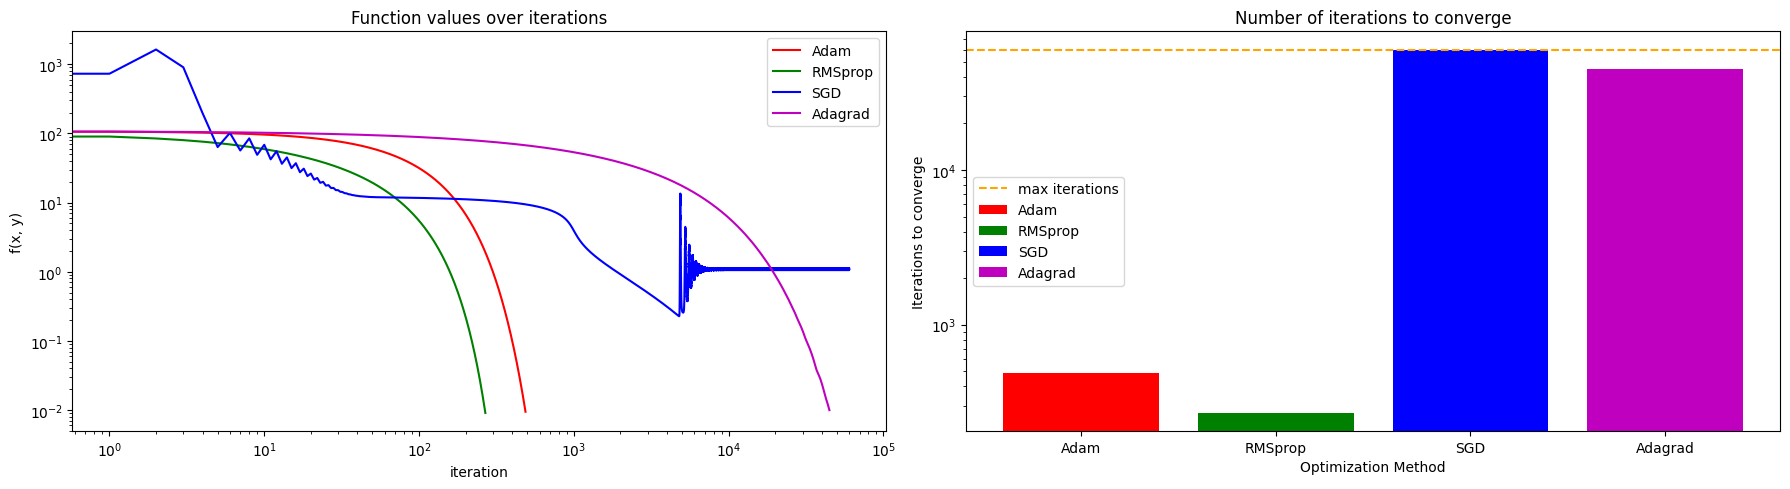

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(18, 5))
ax[0].set_title("Function values over iterations")
ax[1].set_title("Number of iterations to converge")

colors = ["r", "g", "b", "m"]

for method in methods:
    ax[0].plot(
        function_values[method], label=method, color=colors[methods.index(method)]
    )
    ax[1].bar(
        method,
        iterations_number[method],
        label=method,
        color=colors[methods.index(method)],
    )

ax[0].set_xlabel("iteration")
ax[0].set_ylabel("f(x, y)")
ax[0].set_yscale("log")
ax[0].set_xscale("log")

ax[1].set_ylabel("f(x, y)")
ax[1].set_xlabel("Optimization Method")
ax[1].set_ylabel("Iterations to converge")
ax[1].set_yscale("log")
ax[1].axhline(y=num_iterations, color="orange", linestyle="--", label="max iterations")

ax[0].legend()
ax[1].legend()


plt.tight_layout()

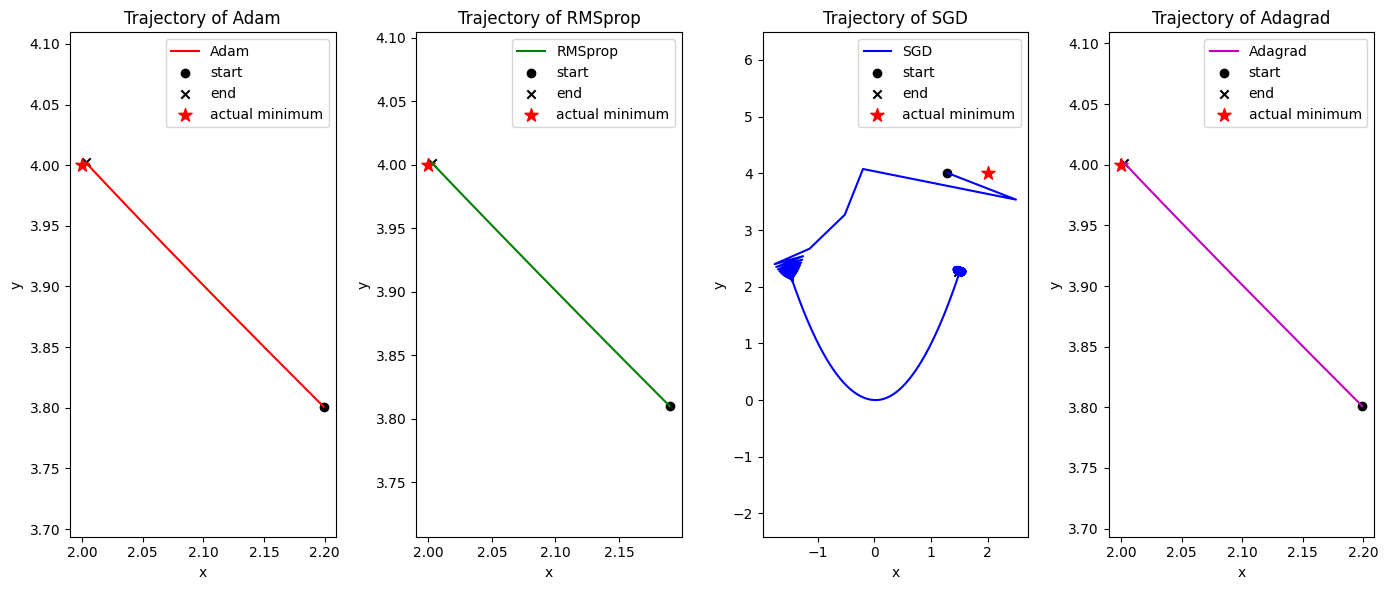

In [5]:
fig, ax = plt.subplots(1, 4, figsize=(14, 6))

actual_minima = torch.tensor([2.0, 4.0])

for method in methods:
    axi = ax[methods.index(method)]
    trajectory = torch.tensor(trajectories[method])
    max_x = trajectory[:, 0].max()
    min_x = trajectory[:, 0].min()

    max_y = trajectory[:, 1].max()
    min_y = trajectory[:, 1].min()

    axi.plot(
        trajectory[:, 0],
        trajectory[:, 1],
        label=method,
        color=colors[methods.index(method)],
    )
    axi.scatter(
        trajectory[0, 0],
        trajectory[0, 1],
        marker="o",
        color="black",
        label="start",
    )
    axi.scatter(
        trajectory[-1, 0],
        trajectory[-1, 1],
        marker="x",
        color="black",
        label="end",
    )

    axi.scatter(
        actual_minima[0],
        actual_minima[1],
        marker="*",
        color="red",
        s=100,
        label="actual minimum",
    )
    axi.set_title(f"Trajectory of {method}")
    axi.set_xlabel("x")
    axi.set_ylabel("y")

    axi.legend()
    axi.set_aspect("equal", adjustable="datalim")
plt.tight_layout()

As you can observe, different optimization methods have different convergence behaviors and performance on the Rosenbrock function. Some methods may converge faster to the minimum, while others may struggle to find the optimal solution due to the non-convex nature of the function. By comparing the trajectories and function values, we can gain insights into the strengths and weaknesses of each optimization method in this specific optimization problem.